In [1]:
! pip install transformers datasets evaluate

In [2]:
from datasets import load_dataset, Audio
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    log_loss,
    brier_score_loss
)

wandb.login(key="97c0d73ce3f332743f73aed9bfd6ffb011ebafb4")

minds = load_dataset("PolyAI/minds14", name="en-US", split="train")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: jarif. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [3]:
minds = minds.train_test_split(test_size=0.2)

In [4]:
minds

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 450
    })
    test: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 113
    })
})

In [5]:
minds = minds.remove_columns(["path", "transcription", "english_transcription", "lang_id"])

In [6]:
minds

DatasetDict({
    train: Dataset({
        features: ['audio', 'intent_class'],
        num_rows: 450
    })
    test: Dataset({
        features: ['audio', 'intent_class'],
        num_rows: 113
    })
})

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


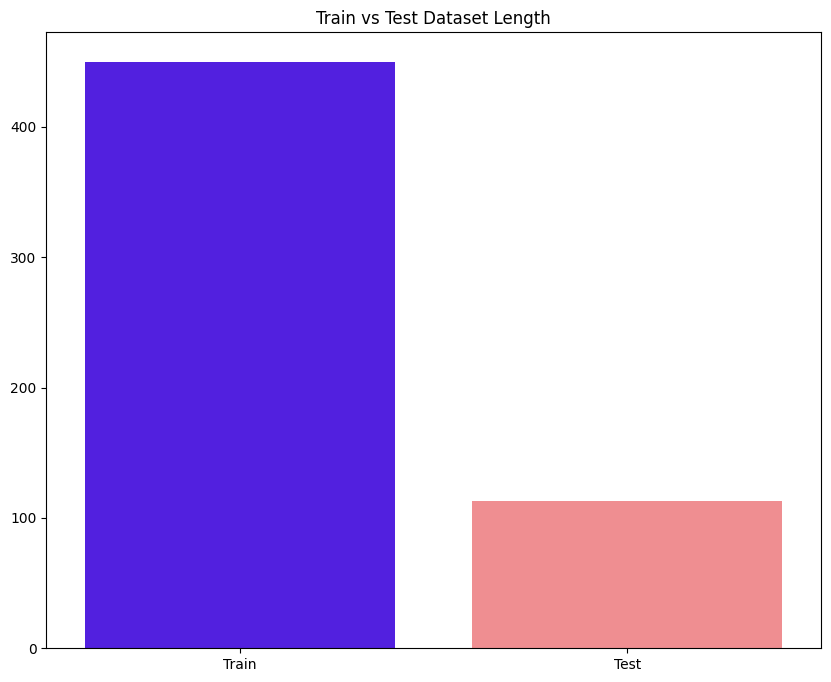

In [7]:

plt.figure(figsize=(10,8))
train_len = len(minds['train'])
test_len = len(minds['test'])

data = {'Dataset': ['Train', 'Test'], 'Length': [train_len, test_len]}

sns.barplot(x='Dataset', y='Length', data=data,palette="gnuplot2")
plt.title('Train vs Test Dataset Length')
plt.show()


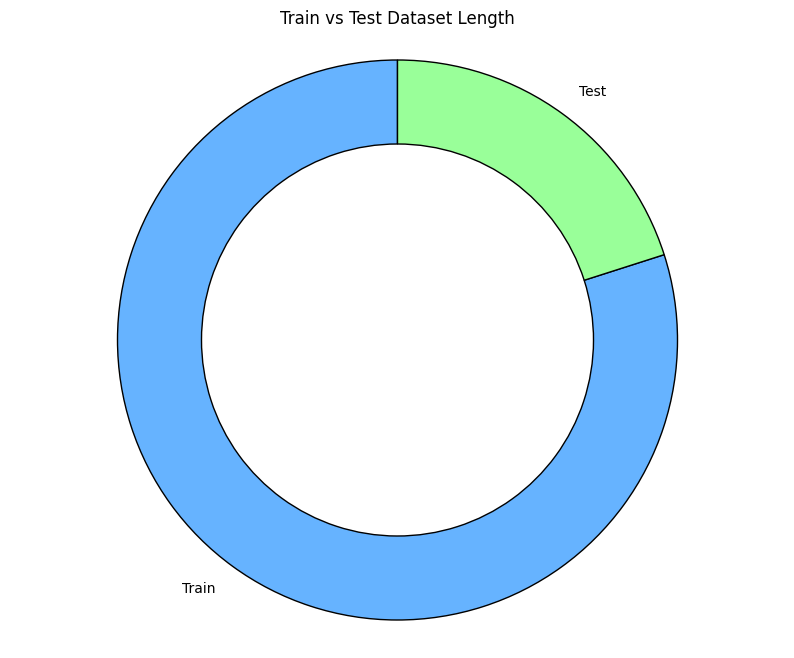

In [8]:
labels = ['Train', 'Test']
sizes = [train_len, test_len]
colors = ['#66b3ff', '#99ff99']

fig, ax = plt.subplots(figsize=(10,8))

ax.pie(sizes, labels=labels, colors=colors, startangle=90, wedgeprops={'width': 0.3, 'edgecolor': 'black'})
ax.set_title('Train vs Test Dataset Length')
ax.axis("equal")

plt.show()

In [9]:
minds["train"][0]

{'audio': {'path': '/root/.cache/huggingface/datasets/downloads/extracted/f9018fd3747971e77d59e6c5da3fdf9d5bb914c495e16c23e1fe47c921d76a7a/en-US~ABROAD/602ba898bb1e6d0fbce92101.wav',
  'array': array([ 0.        , -0.00024414, -0.00024414, ...,  0.        ,
          0.00024414,  0.00024414]),
  'sampling_rate': 8000},
 'intent_class': 0}

## There are two fields:

* audio: a 1-dimensional array of the speech signal that must be called to load and resample the audio file.
* intent_class: represents the class id of the speaker’s intent.
#### To make it easier for the model to get the label name from the label id, create a dictionary that maps the label name to an integer and vice versa:

In [10]:
labels = minds["train"].features["intent_class"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [11]:
id2label[str(2)]

'app_error'

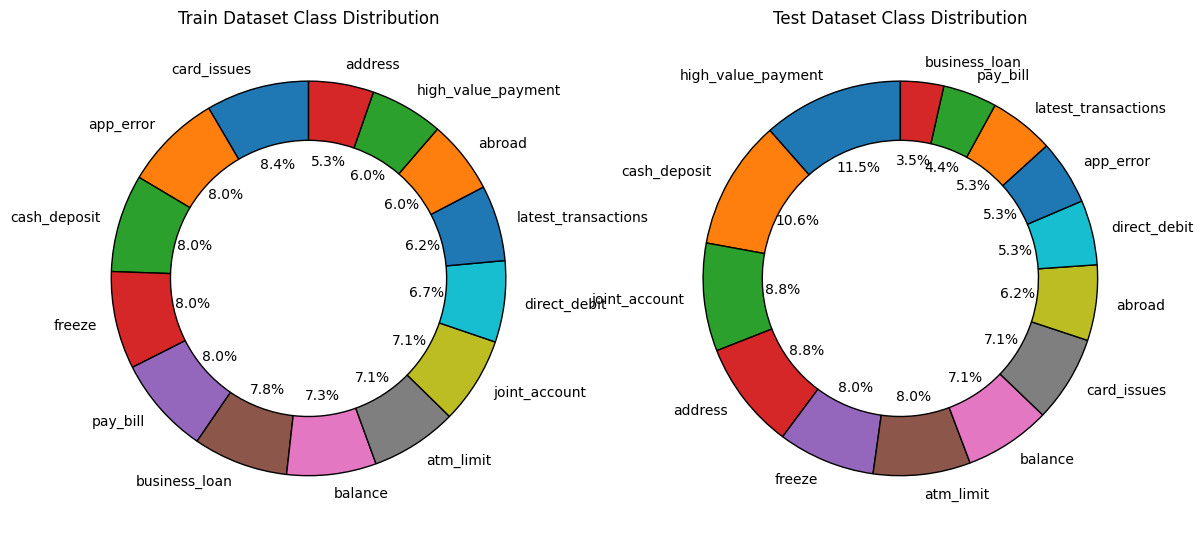

In [12]:

labels = minds["train"].features["intent_class"].names
label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

train_classes = pd.Series([item['intent_class'] for item in minds['train']]).value_counts()
test_classes = pd.Series([item['intent_class'] for item in minds['test']]).value_counts()

train_class_sizes = train_classes.tolist()
test_class_sizes = test_classes.tolist()

train_class_names = [id2label[str(i)] for i in train_classes.index]
test_class_names = [id2label[str(i)] for i in test_classes.index]

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].pie(train_class_sizes, labels=train_class_names, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3, 'edgecolor': 'black'})
ax[0].set_title('Train Dataset Class Distribution')

ax[1].pie(test_class_sizes, labels=test_class_names, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.3, 'edgecolor': 'black'})
ax[1].set_title('Test Dataset Class Distribution')

plt.show()


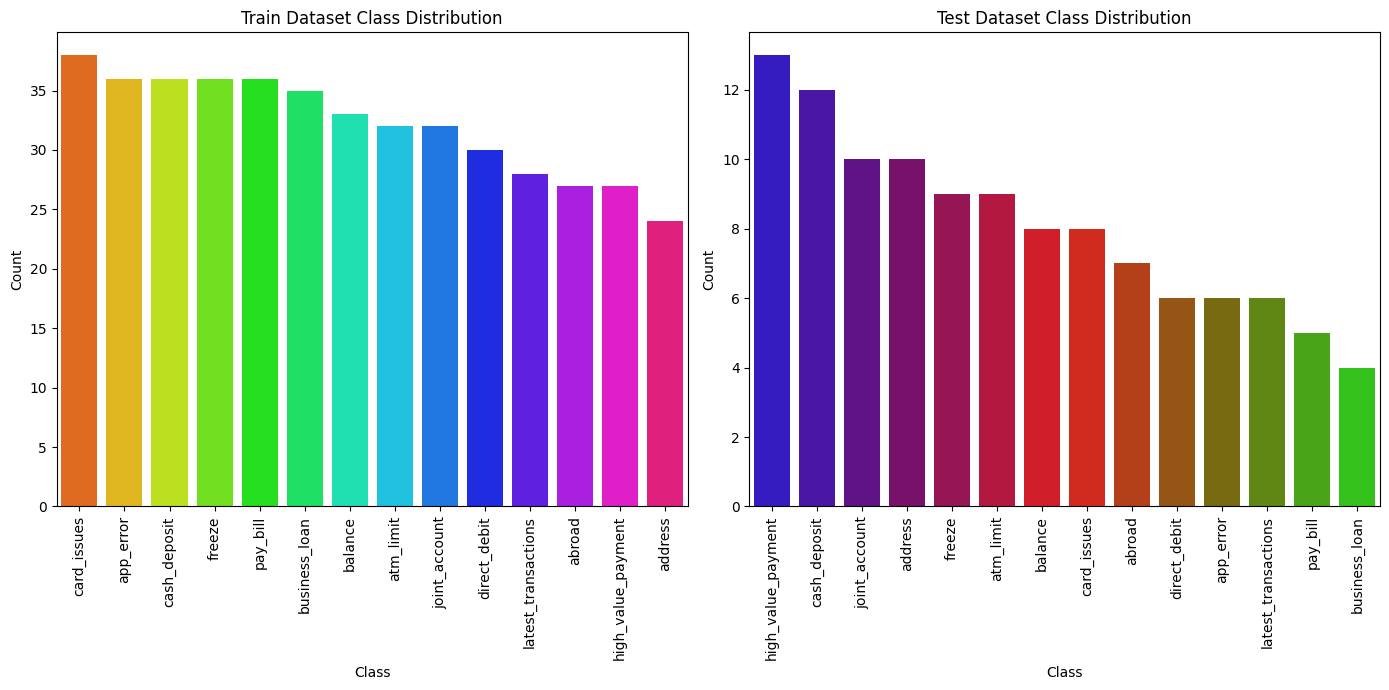

In [13]:


labels = minds["train"].features["intent_class"].names
label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

train_classes = pd.Series([item['intent_class'] for item in minds['train']]).value_counts()
test_classes = pd.Series([item['intent_class'] for item in minds['test']]).value_counts()

train_class_names = [id2label[str(i)] for i in train_classes.index]
test_class_names = [id2label[str(i)] for i in test_classes.index]

train_df = pd.DataFrame({'Class': train_class_names, 'Count': train_classes.tolist()})
test_df = pd.DataFrame({'Class': test_class_names, 'Count': test_classes.tolist()})

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(x='Class', y='Count', data=train_df, ax=ax[0], palette='hsv')
ax[0].set_title('Train Dataset Class Distribution')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)

sns.barplot(x='Class', y='Count', data=test_df, ax=ax[1], palette='brg')
ax[1].set_title('Test Dataset Class Distribution')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()


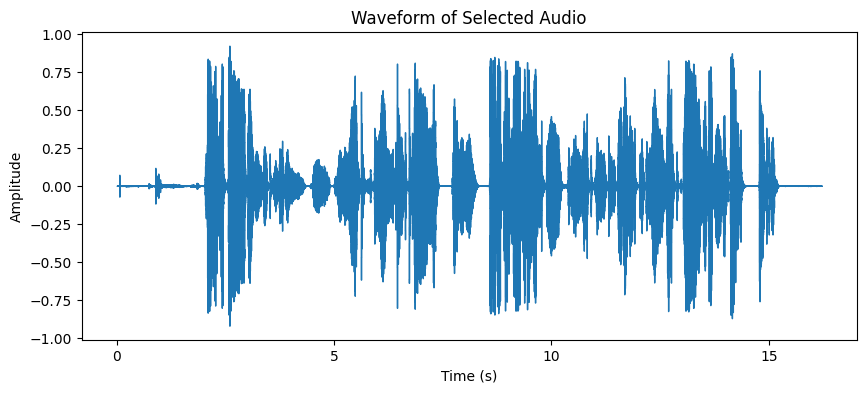

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

audio_sample = minds['train'][0]
audio_path = audio_sample['audio']['path']
y, sr = librosa.load(audio_path)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform of Selected Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

Audio(audio_path)


# Preprocess

In [15]:

from transformers import AutoFeatureExtractor
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

#### The MInDS-14 dataset has a sampling rate of 8kHz (you can find this information in its dataset card), which means you’ll need to resample the dataset to 16kHz to use the pretrained Wav2Vec2 model:

In [16]:
from datasets import Audio
minds = minds.cast_column("audio", Audio(sampling_rate=16000))  # Note: no underscore
minds["train"][0]

{'audio': {'path': '/root/.cache/huggingface/datasets/downloads/extracted/f9018fd3747971e77d59e6c5da3fdf9d5bb914c495e16c23e1fe47c921d76a7a/en-US~ABROAD/602ba898bb1e6d0fbce92101.wav',
  'array': array([-2.46873242e-07, -1.05235536e-04, -2.44102412e-04, ...,
          2.98825675e-04,  2.37689281e-04,  1.11417277e-04]),
  'sampling_rate': 16000},
 'intent_class': 0}

### Now create a preprocessing function that:

* Calls the audio column to load, and if necessary, resample the audio file.
* Checks if the sampling rate of the audio file matches the sampling rate of the audio data a model was pretrained with. You can find this information in the Wav2Vec2 model card.
* Set a maximum input length to batch longer inputs without truncating them.

In [17]:
def preprocess_function(examples):
    audio_arrays = [x["array"] for x in examples["audio"]]
    inputs = feature_extractor(audio_arrays, sampling_rate=feature_extractor.sampling_rate, max_length=16000, truncation=True)
    return inputs

#### To apply the preprocessing function over the entire dataset, use 🤗 Datasets map function. You can speed up map by setting batched=True to process multiple elements of the dataset at once. Remove unnecessary columns and rename intent_class to label, as required by the model:

In [18]:
encoded_minds = minds.map(preprocess_function, remove_columns="audio", batched=True)
encoded_minds = encoded_minds.rename_column("intent_class", "label")

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

# Evaluate

#### Including a metric during training is often helpful for evaluating your model’s performance. You can quickly load an evaluation method with the 🤗 Evaluate library. For this task, load the accuracy metric (see the 🤗 Evaluate quick tour to learn more about how to load and compute a metric):

In [19]:
import evaluate

accuracy = evaluate.load("accuracy")

import numpy as np


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=eval_pred.label_ids)

In [20]:
from transformers import AutoModelForAudioClassification, TrainingArguments, Trainer

num_labels = len(id2label)
model = AutoModelForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593", num_labels=num_labels, label2id=label2id, id2label=id2label,ignore_mismatched_sizes=True)

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([14]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([14, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### At this point, only three steps remain:

* Define your training hyperparameters in TrainingArguments. The only required parameter is output_dir, which specifies where to save your model. You’ll push this model to the Hub by setting push_to_hub=True (you need to be signed in to Hugging Face to upload your model). At the end of each epoch, the Trainer will evaluate the accuracy and save the training checkpoint.
* Pass the training arguments to Trainer along with the model, dataset, tokenizer, data collator, and compute_metrics function.
* Call train() to fine-tune your model.

In [21]:
training_args = TrainingArguments(
    output_dir="my_awesome_mind_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=4,
    num_train_epochs=15,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    weight_decay=0.02,
    fp16=True
)

In [22]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_minds["train"],
    eval_dataset=encoded_minds["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

In [23]:

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss,Accuracy
1,2.894300,2.903709,0.088496
2,2.723300,2.714083,0.035398
3,2.689100,2.631110,0.115044
4,2.581900,2.812751,0.061947
5,2.667000,2.703730,0.070796
6,2.443500,2.762402,0.097345
7,2.560600,2.591209,0.132743
8,2.468600,2.779980,0.070796
9,2.308400,2.842300,0.141593
10,1.869200,3.063049,0.132743


TrainOutput(global_step=420, training_loss=1.9415018332856042, metrics={'train_runtime': 1620.6317, 'train_samples_per_second': 4.165, 'train_steps_per_second': 0.259, 'total_flos': 4.422625934054523e+17, 'train_loss': 1.9415018332856042, 'epoch': 14.495575221238939})

In [24]:
import os
os.makedirs("/kaggle/working/models",exist_ok=True)

In [25]:
trainer.save_model("/kaggle/working/models")
loaded_model = AutoModelForAudioClassification.from_pretrained(
    "/kaggle/working/models",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
loaded_model

ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTSdpaAttention(
            (attention): ASTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
       

In [26]:
loaded_trainer = Trainer(
   model=loaded_model,
   args=training_args,
   processing_class=feature_extractor,
   eval_dataset=encoded_minds["test"])

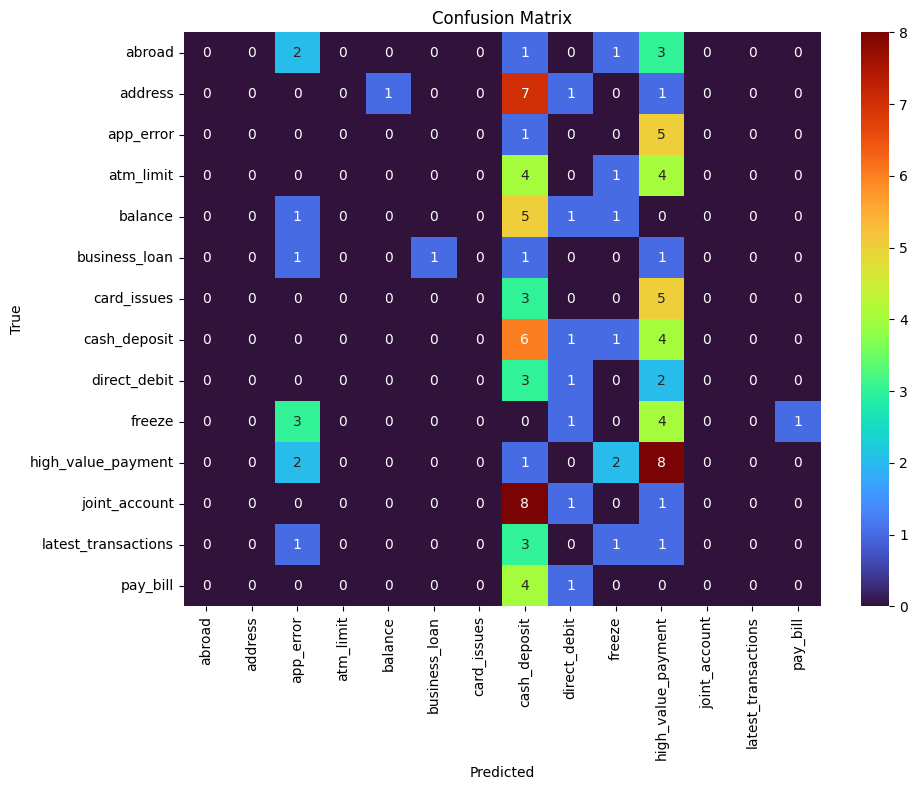

In [27]:
predictions = loaded_trainer.predict(encoded_minds["test"])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='turbo',xticklabels=list(id2label.values()),yticklabels=list(id2label.values()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [28]:
label_name=list(id2label.values())
label_name

['abroad',
 'address',
 'app_error',
 'atm_limit',
 'balance',
 'business_loan',
 'card_issues',
 'cash_deposit',
 'direct_debit',
 'freeze',
 'high_value_payment',
 'joint_account',
 'latest_transactions',
 'pay_bill']

In [29]:
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels,target_names=list(id2label.values())))


Classification Report:
                     precision    recall  f1-score   support

             abroad       0.00      0.00      0.00         7
            address       0.00      0.00      0.00        10
          app_error       0.00      0.00      0.00         6
          atm_limit       0.00      0.00      0.00         9
            balance       0.00      0.00      0.00         8
      business_loan       1.00      0.25      0.40         4
        card_issues       0.00      0.00      0.00         8
       cash_deposit       0.13      0.50      0.20        12
       direct_debit       0.14      0.17      0.15         6
             freeze       0.00      0.00      0.00         9
 high_value_payment       0.21      0.62      0.31        13
      joint_account       0.00      0.00      0.00        10
latest_transactions       0.00      0.00      0.00         6
           pay_bill       0.00      0.00      0.00         5

           accuracy                           0.14       11

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')
f1 = f1_score(true_labels, pred_labels, average='weighted')

print("=======================================================================================")
print(f"\nOverall Metrics:")
print("=======================================================================================")
print(f"Accuracy: {accuracy:.4f}")
print("=======================================================================================")
print(f"Precision: {precision:.4f}")
print("=======================================================================================")
print(f"Recall: {recall:.4f}")
print("=======================================================================================")
print(f"F1-Score: {f1:.4f}")
print("=======================================================================================")


Overall Metrics:
Accuracy: 0.1416
Precision: 0.0801
Recall: 0.1416
F1-Score: 0.0793


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Roc curve

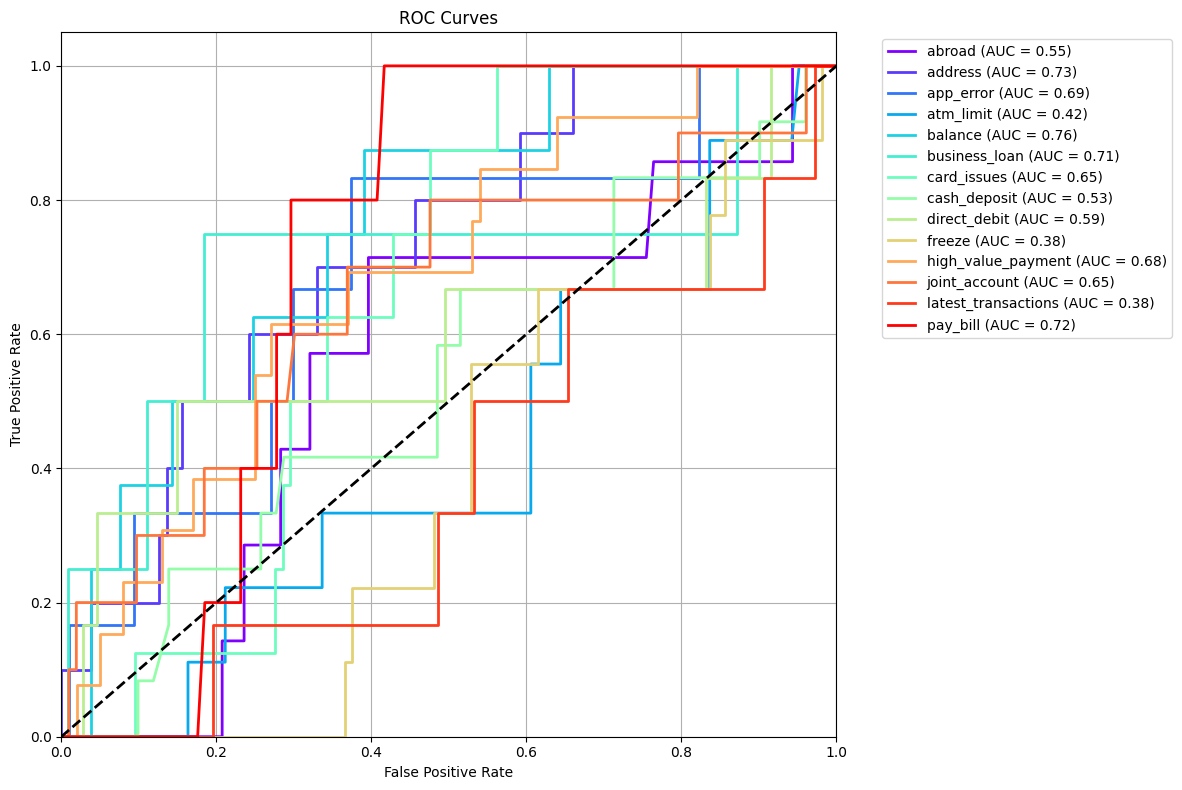

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


y_test = label_binarize(true_labels, classes=np.arange(len(id2label)))
y_score = predictions.predictions

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(12, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, len(id2label)))

for i, color in enumerate(colors):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,label=f'{list(id2label.values())[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# precision recall curve

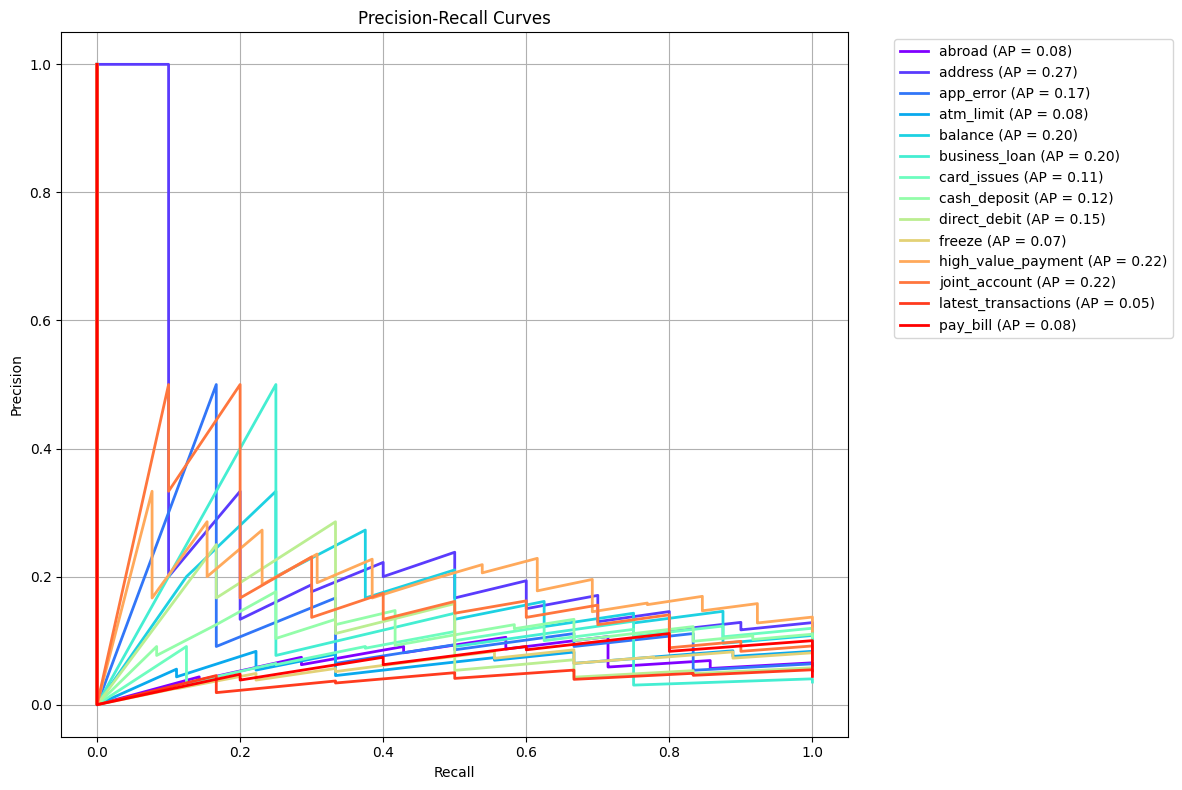

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_test = label_binarize(true_labels, classes=np.arange(len(id2label)))
y_score = predictions.predictions

precision = {}
recall = {}
avg_precision = {}

plt.figure(figsize=(12, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, len(id2label)))

for i, color in enumerate(colors):
   precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[:, i])
   avg_precision[i] = average_precision_score(y_test[:, i], y_score[:, i])
   plt.plot(recall[i], precision[i], color=color, lw=2,
            label=f'{list(id2label.values())[i]} (AP = {avg_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Custom Data Prediction

In [59]:
import torchaudio
import torch
from datasets import Dataset

def predict_audio_intent(test_file, loaded_trainer, id2label, feature_extractor):
   waveform, sample_rate = torchaudio.load(test_file)
   
   if waveform.shape[0] > 1:
       waveform = torch.mean(waveform, dim=0, keepdim=True)
   
   if sample_rate != 16000:
       resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
       waveform = resampler(waveform)
       
   processed = feature_extractor(waveform.squeeze().numpy(), sampling_rate=16000, return_tensors="pt")
   
   dataset = Dataset.from_dict({
       "input_values": [processed.input_values.squeeze()]
   })
   
   with torch.no_grad():
       predictions = loaded_trainer.predict(dataset)
       logits = torch.tensor(predictions.predictions[0])
       predicted_class_idx = torch.argmax(logits).item()
       label_names = ['abroad', 'address', 'app_error', 'atm_limit', 'balance', 
                     'business_loan', 'card_issues', 'cash_deposit', 'direct_debit',
                     'freeze', 'high_value_payment', 'joint_account', 
                     'latest_transactions', 'pay_bill']
       predicted_label = label_names[predicted_class_idx]
   
   return predicted_label

test_file = "/kaggle/input/custom-image-dataset/test.mp3" 
predicted_label = predict_audio_intent(test_file, loaded_trainer, id2label, feature_extractor)
print(f"Predicted Intent: {predicted_label}")

Predicted Intent: freeze
